# Задача 6. BFS on GPU

- Используя `OpenCL` или `CUDA` реализовать алгоритм обхода в ширину ориентированного графа на GPU. Реализация не обязательно должна использовать операции линейной алгебры, можно взять классический алгоритм BFS.
- Провести экспериментальное исследование полученной реализации и сравнить её с реализацией этого же алгоритма на CPU. Графы брать разного размера, например с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/). На некоторых графах добиться прироста производительности при использовании GPU.

### Настройка виртуального окружения

```bash
python -m venv .venv
source .venv/Scripts/activate
pip install -r req.txt
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
from collections import deque
import glob
import time
import os

import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.sparse import csr_matrix
from prettytable import PrettyTable
import warnings
from numba.core.errors import NumbaPerformanceWarning
warnings.filterwarnings('ignore', category=NumbaPerformanceWarning)

In [74]:
def bfs_cpu(row_ptr, col_indices, start_vertex, n_vertices):
    
    distances = np.full(n_vertices, -1, dtype = np.int32)
    queue = deque()
    
    distances[start_vertex] = 0
    queue.append(start_vertex)
    
    while queue:
        u = queue.popleft()

        for idx in range(row_ptr[u], row_ptr[u + 1]):
            v = col_indices[idx]
            
            if distances[v] == -1:
                distances[v] = distances[u] + 1
                queue.append(v)
    
    return distances

In [75]:
# cuda ядро для одного уровня BFS
@cuda.jit
def bfs_gpu_kernel(row_ptr, col_indices, distances, queue, queue_size, next_queue, next_queue_size, current_level):
    tid = cuda.grid(1)
    if tid >= queue_size[0]:
        return
    
    u = queue[tid]
    for idx in range(row_ptr[u], row_ptr[u + 1]):
        v = col_indices[idx]
        old_val = cuda.atomic.cas(distances, v, -1, current_level + 1)
        if old_val == -1:
            pos = cuda.atomic.add(next_queue_size, 0, 1)
            next_queue[pos] = v

# класс для BFS на GPU с предварительной загрузкой графа
class BFSGPU:
    def __init__(self, row_ptr, col_indices, n_vertices):
        self.n_vertices = int(n_vertices)
        self.n_edges = int(len(col_indices))
        
        # перенос графа на GPU
        self.d_row_ptr = cuda.to_device(row_ptr)
        self.d_col_indices = cuda.to_device(col_indices)
        
        self.d_queue1 = None
        self.d_queue2 = None
    
    def bfs(self, start_vertex):
        start_vertex = int(start_vertex)
        if self.d_queue1 is None:
            self.d_queue1 = cuda.device_array(self.n_vertices, dtype = np.int32)
            self.d_queue2 = cuda.device_array(self.n_vertices, dtype = np.int32)
        
        d_distances = cuda.device_array(self.n_vertices, dtype = np.int32)
        d_distances[:] = -1
        d_distances[start_vertex] = 0
        
        self.d_queue1[0] = start_vertex
        
        d_queue_size = cuda.device_array(1, dtype = np.int32)
        d_next_queue_size = cuda.device_array(1, dtype = np.int32)
        d_queue_size[0] = 1
        d_next_queue_size[0] = 0
        
        current_level = 0
        current_queue = self.d_queue1
        next_queue = self.d_queue2
        threads_per_block = 256
        
        while d_queue_size[0] > 0:
            blocks = (d_queue_size[0] + threads_per_block - 1) // threads_per_block
            bfs_gpu_kernel[blocks, threads_per_block](
                self.d_row_ptr, self.d_col_indices,
                d_distances,
                current_queue, d_queue_size,
                next_queue, d_next_queue_size,
                current_level,
            )
            cuda.synchronize()
            
            current_level += 1
            d_queue_size[0] = d_next_queue_size[0]
            d_next_queue_size[0] = 0
            current_queue, next_queue = next_queue, current_queue
        
        return d_distances.copy_to_host()

### CPU vs GPU BFS

In [76]:
# загрузка графа
def load_mtx_as_csr(path: str, make_undirected: bool = True, drop_self_loops: bool = True):
    
    A = mmread(path)
    if not hasattr(A, "tocsr"):
        A = np.asarray(A)
        A = csr_matrix(A)
    else:
        A = A.tocsr()
    
    if A.shape[0] != A.shape[1]:
        raise ValueError(f"Adjacency matrix must be square, got {A.shape} for {path}")
    
    A.data = np.ones_like(A.data, dtype = np.int8)
    
    if drop_self_loops:
        A.setdiag(0)
        A.eliminate_zeros()
    
    if make_undirected:
        A = A.maximum(A.T)
    
    A.sort_indices()
    return A

In [77]:
# преобразование csr-матрицы в массивы для передачи на GPU
def csr_to_csr_arrays(A: csr_matrix):
    row_ptr = A.indptr.astype(np.int32, copy = False)
    col_indices = A.indices.astype(np.int32, copy = False)
    return row_ptr, col_indices

In [78]:
# метрики графа
def graph_metrics(A: csr_matrix):
    n = int(A.shape[0])
    m = int(A.nnz)
    density = (m / (n * n)) if n > 0 else 0.0
    sparsity = 1.0 - density
    avg_degree = (m / n) if n > 0 else 0.0
    return {
        "n": n,
        "m": m,
        "density": density,
        "sparsity": sparsity,
        "avg_degree": avg_degree,
    }

In [79]:
# выбор стартовой вершины для BFS (первая с ненулевой степенью)
def choose_start_vertex(A: csr_matrix):
    deg = np.diff(A.indptr)
    nz = np.flatnonzero(deg > 0)
    return int(nz[0]) if nz.size else 0

In [80]:
# построение биннингованной тепловой карты смежности
def binned_heatmap(A: csr_matrix, bins: int = 256):
    n = int(A.shape[0])
    rows, cols = A.nonzero()
    if n <= bins:
        H = np.zeros((n, n), dtype = np.uint8)
        H[rows, cols] = 1
        return H.astype(np.int32)
    
    rbin = (rows.astype(np.int64) * bins) // n
    cbin = (cols.astype(np.int64) * bins) // n
    H = np.zeros((bins, bins), dtype = np.int32)
    np.add.at(H, (rbin, cbin), 1)
    return H

def plot_heatmap(H: np.ndarray, title: str):
    plt.figure(figsize = (6, 5))
    plt.imshow(np.log1p(H), cmap = "magma", origin = "lower", aspect = "auto")
    plt.colorbar(label = "log(1 + nnz in bin)")
    plt.title(title)
    plt.xlabel("col bins")
    plt.ylabel("row bins")
    plt.tight_layout()

In [81]:
def time_call(fn, repeats: int = 3):
   
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append((time.perf_counter() - t0) * 1e3)
    return float(np.median(times))

def benchmark_bfs(row_ptr, col_indices, n: int, start: int, gpu_enabled: bool = True):
    out = {}
  
    cpu_dist = bfs_cpu(row_ptr, col_indices, start, n)
    
    repeats_cpu = 3 if n <= 200_000 else 1
    out["cpu_ms"] = time_call(lambda: bfs_cpu(row_ptr, col_indices, start, n), repeats=repeats_cpu)
    out["reachable"] = int(np.sum(cpu_dist >= 0))
    
    out["gpu_ms"] = None
    out["speedup"] = None
    out["correct"] = None
    out["gpu_note"] = ""
    
    try:
        gpu = BFSGPU(row_ptr, col_indices, n)
        _ = gpu.bfs(start)
        cuda.synchronize()
        repeats_gpu = 3 if n <= 200_000 else 1
        gpu_ms = time_call(lambda: gpu.bfs(start), repeats=repeats_gpu)
        out["gpu_ms"] = gpu_ms
        out["speedup"] = (out["cpu_ms"] / gpu_ms) if gpu_ms and gpu_ms > 0 else None
        gpu_dist = gpu.bfs(start)
        out["correct"] = bool(np.array_equal(cpu_dist, gpu_dist))
    except Exception as e:
        out["gpu_note"] = f"GPU run failed: {type(e).__name__}: {e}"

    return out

1138_bus.mtx


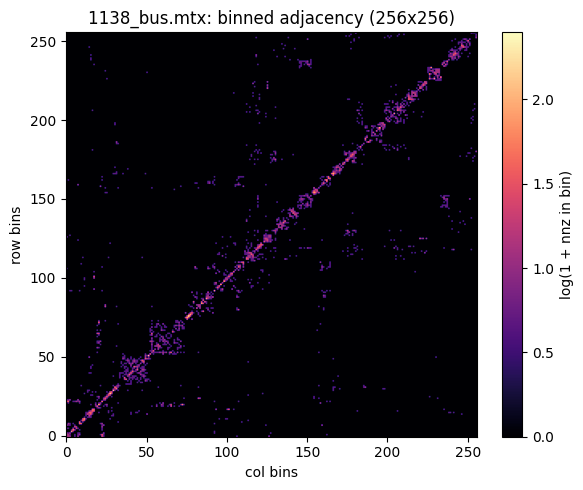

auto.mtx


d:\Pythons\Python-3.10\lib\site-packages\scipy\sparse\_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


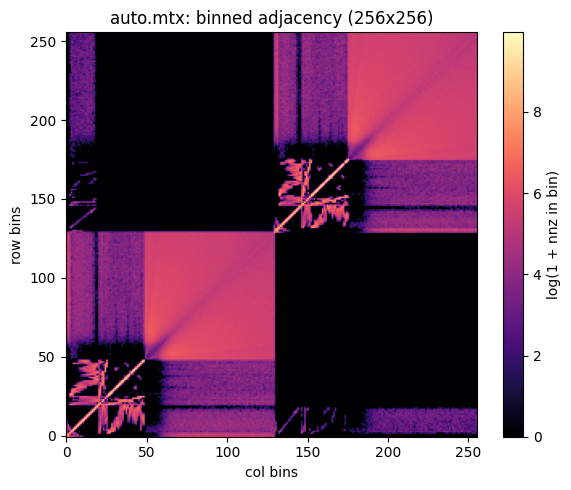

bcspwr07.mtx


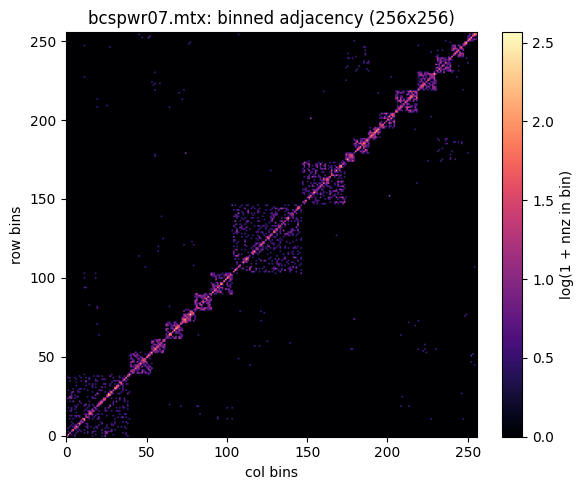

delaunay_n20.mtx


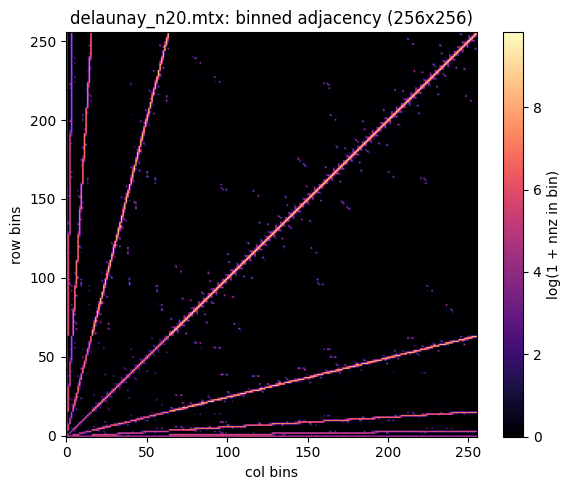

In [82]:
DATA_DIR = os.path.join(os.getcwd(), "data")

mtx_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mtx")))

results = []
for path in mtx_files:
    name = os.path.basename(path)
    print(name)
    A = load_mtx_as_csr(path, make_undirected=True, drop_self_loops=True)
    metrics = graph_metrics(A)
    start = choose_start_vertex(A)
    row_ptr, col_indices = csr_to_csr_arrays(A)
    bench = benchmark_bfs(row_ptr, col_indices, metrics["n"], start, gpu_enabled=gpu_available)
    H = binned_heatmap(A, bins=256)
    plot_heatmap(H, title=f"{name}: binned adjacency (256x256)")
    plt.show()
    
    results.append({
        "graph": name,
        **metrics,
        "start": start,
        "reachable": bench["reachable"],
        "cpu_ms": bench["cpu_ms"],
        "gpu_ms": bench["gpu_ms"],
        "speedup": bench["speedup"],
        "correct": bench["correct"],
        "gpu_note": bench["gpu_note"],
    })

In [83]:
table = PrettyTable()
table.field_names = ["graph", "n", "m", "avg_degree", "density", "sparsity", "reachable", "cpu_ms", "gpu_ms", "speedup", "correct"]
for r in results:
    table.add_row([
        r["graph"],
        r["n"],
        r["m"],
        f"{r['avg_degree']:.2f}",
        f"{r['density']:.2e}",
        f"{r['sparsity']:.6f}",
        r["reachable"],
        f"{r['cpu_ms']:.2f}",
        "-" if r["gpu_ms"] is None else f"{r['gpu_ms']:.2f}",
        "-" if r["speedup"] is None else f"{r['speedup']:.2f}x",
        "-" if r["correct"] is None else str(r["correct"]),
    ])
print("Сводная таблица:")
table

Сводная таблица:


graph,n,m,avg_degree,density,sparsity,reachable,cpu_ms,gpu_ms,speedup,correct
1138_bus.mtx,1138,2916,2.56,2.25e-03,0.997748,1138,1.55,37.76,0.04x,True
auto.mtx,448695,6629222,14.77,3.29e-05,0.999967,448695,1793.98,87.04,20.61x,True
bcspwr07.mtx,1612,4212,2.61,1.62e-03,0.998379,1612,1.94,47.57,0.04x,True
delaunay_n20.mtx,1048576,6291372,6.00,5.72e-06,0.999994,1048576,2153.02,597.84,3.60x,True


### Вывод

- **маленькие графы** (1138_bus, bcspwr07): CPU быстрее GPU в 16-25 раз (ускорение 0.04-0.06x) из-за накладных расходов
- **средний граф auto** (448k вершин, степень 14.8): GPU выигрывает с ускорением **9x**
- **большой граф delaunay_n20** (1M вершин, степень 6.0): ускорение **3.3x** - положительно, но меньше из-за низкой степени вершин
- **главный фактор ускорения** - средняя степень вершины, а не размер графа или разреженность
- **все результаты корректны**